# Corporate Credit Rating — Regression Track
## Predicting Numeric Credit Rating Score (Rating_Score)

This notebook loads the preprocessed corporate financial dataset and builds, compares, tunes, and evaluates 10 regression models to predict corporate credit rating scores from financial indicators.

## 1. Import Libraries

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error
)

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load Preprocessed Regression Dataset

Loading the preprocessed, encoded, and scaled training and test sets generated by `preprocessing.ipynb`.

In [6]:
data_dir = '../data' if os.path.exists('../data') else 'data'

train_df = pd.read_csv(os.path.join(data_dir, 'train_regression_preprocessed.csv'))
test_df = pd.read_csv(os.path.join(data_dir, 'test_regression_preprocessed.csv'))

# Features and Targets
X_train_r = train_df.drop(columns=['Rating_Score'])
y_train_r = train_df['Rating_Score']

X_test_r = test_df.drop(columns=['Rating_Score'])
y_test_r = test_df['Rating_Score']

# Scaled feature arrays for model fitting
X_train_r_scaled = X_train_r.values
X_test_r_scaled = X_test_r.values

print(f'Loaded preprocessed regression data from {data_dir}:')
print(f'Training set: X = {X_train_r.shape}, y = {y_train_r.shape}')
print(f'Testing set:  X = {X_test_r.shape}, y = {y_test_r.shape}')

Loaded preprocessed regression data from ../data:
Training set: X = (6244, 29), y = (6244,)
Testing set:  X = (1561, 29), y = (1561,)


## 15. Regression Models

In [7]:
reg_models = {}
reg_results = []

def add_reg_result(name, model, preds):
    reg_models[name] = model

    r2 = r2_score(y_test_r, preds)
    rmse = np.sqrt(mean_squared_error(y_test_r, preds))
    mae = mean_absolute_error(y_test_r, preds)

    reg_results.append([name, r2, rmse, mae])

    print(name)
    print("R2:", r2)
    print("RMSE:", rmse)
    print("MAE:", mae)
    print()

### 15.1 Linear Regression

In [8]:
lr_model = LinearRegression()
lr_model.fit(X_train_r_scaled, y_train_r)
lr_preds = lr_model.predict(X_test_r_scaled)

add_reg_result("Linear Regression", lr_model, lr_preds)

Linear Regression
R2: 0.3473613257217645
RMSE: 3.0336741077762106
MAE: 2.3208045466855802



### 15.2 Ridge Regression

In [9]:
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train_r_scaled, y_train_r)
ridge_preds = ridge_model.predict(X_test_r_scaled)

add_reg_result("Ridge Regression", ridge_model, ridge_preds)

Ridge Regression
R2: 0.3473933528130887
RMSE: 3.0335996707611037
MAE: 2.320823950141867



### 15.3 Lasso Regression

In [10]:
lasso_model = Lasso(alpha=0.1, random_state=42)
lasso_model.fit(X_train_r_scaled, y_train_r)
lasso_preds = lasso_model.predict(X_test_r_scaled)

add_reg_result("Lasso Regression", lasso_model, lasso_preds)

Lasso Regression
R2: 0.3310065234198615
RMSE: 3.0714500964016853
MAE: 2.374557708333101



In [11]:
# Observe Lasso Feature Sparsity
zeros = sum(lasso_model.coef_ == 0)
total = len(lasso_model.coef_)
print(f'Lasso drove {zeros} out of {total} features exactly to zero.')


Lasso drove 18 out of 29 features exactly to zero.


### 15.4 ElasticNet Regression

In [12]:
from sklearn.model_selection import GridSearchCV

en_grid = {
    'alpha': [0.1, 1.0],
    'l1_ratio': [0.2, 0.5, 0.8]
}

en_search = GridSearchCV(ElasticNet(random_state=42),en_grid, cv=5,scoring='r2'
)

en_search.fit(X_train_r_scaled, y_train_r)
en_preds = en_search.predict(X_test_r_scaled)

add_reg_result("ElasticNet Regression", en_search.best_estimator_, en_preds)
print("Best ElasticNet params:", en_search.best_params_)

ElasticNet Regression
R2: 0.34277136759459104
RMSE: 3.044323216549672
MAE: 2.349274475277215

Best ElasticNet params: {'alpha': 0.1, 'l1_ratio': 0.2}


### 15.5 Polynomial Regression

In [13]:
poly = PolynomialFeatures(degree=2) #highest power of x 
X_train_poly = poly.fit_transform(X_train_r_scaled)
X_test_poly = poly.transform(X_test_r_scaled)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train_r)
poly_preds = poly_model.predict(X_test_poly)

# Store the polynomial model separately
poly_r2 = r2_score(y_test_r, poly_preds)
poly_rmse = np.sqrt(mean_squared_error(y_test_r, poly_preds))
poly_mae = mean_absolute_error(y_test_r, poly_preds)

reg_models["Polynomial Regression"] = poly_model
reg_results.append(["Polynomial Regression", poly_r2, poly_rmse, poly_mae])

print("Polynomial Regression")
print("R2:", poly_r2)
print("RMSE:", poly_rmse)
print("MAE:", poly_mae)

Polynomial Regression
R2: 0.4544282680302243
RMSE: 2.77369339255833
MAE: 2.13511609953479


### Polynomial Degree Comparison

In [14]:
degree_results = []
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for degree in [1, 2]:
    p = PolynomialFeatures(degree=degree)
    xtr_p = p.fit_transform(X_train_r_scaled)
    
    m = LinearRegression()
    # Use cross-validation on train set only to compare degrees
    cv_scores = cross_val_score(m, xtr_p, y_train_r, cv=kf, scoring='r2')
    
    degree_results.append({
        'Degree': degree,
        'Mean CV R2': cv_scores.mean()
    })

pd.DataFrame(degree_results)

,Degree,Mean CV R2
0,1,0.395949
1,2,0.464373


### 15.6 Decision Tree Regressor

In [15]:
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train_r_scaled, y_train_r)
dt_preds = dt_model.predict(X_test_r_scaled)

add_reg_result("Decision Tree Regressor", dt_model, dt_preds)

Decision Tree Regressor
R2: 0.4121769667905375
RMSE: 2.879093849300244
MAE: 2.226427720709174



### 15.7 Random Forest Regressor

In [16]:
rf_model = RandomForestRegressor(
    n_estimators=50, max_depth=10, random_state=42, n_jobs=-1
)
rf_model.fit(X_train_r_scaled, y_train_r)
rf_preds = rf_model.predict(X_test_r_scaled)

add_reg_result("Random Forest Regressor", rf_model, rf_preds)

Random Forest Regressor
R2: 0.6990129482780534
RMSE: 2.060185985169711
MAE: 1.512191212816876



### 15.8 Gradient Boosting Regressor

In [17]:
gb_model = GradientBoostingRegressor(
    n_estimators=50, random_state=42
)
gb_model.fit(X_train_r_scaled, y_train_r)
gb_preds = gb_model.predict(X_test_r_scaled)

add_reg_result("Gradient Boosting Regressor", gb_model, gb_preds)

Gradient Boosting Regressor
R2: 0.5226191772502041
RMSE: 2.5945676946871403
MAE: 2.003247072303853



### 15.9 Support Vector Regressor

In [18]:
svr_model = SVR(kernel='rbf', C=1.0)
svr_model.fit(X_train_r_scaled, y_train_r)
svr_preds = svr_model.predict(X_test_r_scaled)

add_reg_result("Support Vector Regressor", svr_model, svr_preds)

Support Vector Regressor
R2: 0.5352091149596088
RMSE: 2.560125900252675
MAE: 1.923222580313236



### 15.10 K-Nearest Neighbors Regressor

In [19]:
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_r_scaled, y_train_r)
knn_preds = knn_model.predict(X_test_r_scaled)

add_reg_result("KNN Regressor", knn_model, knn_preds)

KNN Regressor
R2: 0.6281809518820538
RMSE: 2.289804156462284
MAE: 1.585906470211403



## 16. Regression Comparison

In [20]:
results_df = pd.DataFrame(
    reg_results,
    columns=['Model', 'R2', 'RMSE', 'MAE']
)

results_df = results_df.sort_values(
    by='R2', ascending=False
).reset_index(drop=True)

results_df

,Model,R2,RMSE,MAE
0,Random Forest Regressor,0.699013,2.060186,1.512191
1,KNN Regressor,0.628181,2.289804,1.585906
2,Support Vector Regressor,0.535209,2.560126,1.923223
3,Gradient Boosting Regressor,0.522619,2.594568,2.003247
4,Polynomial Regression,0.454428,2.773693,2.135116
5,Decision Tree Regressor,0.412177,2.879094,2.226428
6,Ridge Regression,0.347393,3.033600,2.320824
7,Linear Regression,0.347361,3.033674,2.320805
8,ElasticNet Regression,0.342771,3.044323,2.349274
9,Lasso Regression,0.331007,3.071450,2.374558


### Observation

The table ranks all ten regression algorithms using the same held-out test set. A higher R² and lower RMSE/MAE indicate better regression performance.

## 16.1 Linear Regression Coefficients

In [21]:
coef_table = pd.Series(
    lr_model.coef_,
    index=X_train_r.columns
).sort_values(key=abs, ascending=False)

coef_table.head(10)

Long-term Debt / Capital     -1.431402
ROI - Return On Investment    1.385111
Average Profit Margin        -0.831889
Pre-Tax Profit Margin         0.821288
Current Ratio                -0.811109
ROA - Return On Assets       -0.607253
EBITDA Margin                -0.568046
Net Profit Margin             0.520919
EBIT Margin                   0.462747
Gross Margin                  0.403907
dtype: float64

### Interpretation of Linear Regression Coefficients
As seen above, the variables with the largest positive coefficients strongly increase the target rating, while variables with large negative coefficients decrease it. This provides a baseline understanding of what features strongly correlate with a high rating.


### Observation

A positive coefficient means the feature increases the predicted rating score when other features are kept constant. A negative coefficient means the opposite. The size of the coefficient shows its relative effect after scaling.


## 17. Hyperparameter Tuning

In [22]:
# Tune KNN Regressor
knn_grid = {
    'n_neighbors': [3, 5, 7, 9, 11]
}

knn_search = GridSearchCV(
    KNeighborsRegressor(),
    knn_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

knn_search.fit(X_train_r_scaled, y_train_r)

knn_tuned_preds = knn_search.predict(X_test_r_scaled)
knn_tuned_r2 = r2_score(y_test_r, knn_tuned_preds)

print("KNN best parameters:", knn_search.best_params_)

print("KNN before tuning R2:", results_df.loc[
    results_df['Model'] == 'KNN Regressor', 'R2'
].iloc[0])

print("KNN after tuning R2:", knn_tuned_r2)

KNN best parameters: {'n_neighbors': 3}
KNN before tuning R2: 0.6281809518820538
KNN after tuning R2: 0.6547404936935048


In [23]:
# Tune Random Forest
rf_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

rf_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

rf_search.fit(X_train_r_scaled, y_train_r)

rf_tuned_preds = rf_search.predict(X_test_r_scaled)
rf_tuned_r2 = r2_score(y_test_r, rf_tuned_preds)

print("Random Forest best parameters:", rf_search.best_params_)
print("Random Forest before tuning R2:", results_df.loc[
    results_df['Model'] == 'Random Forest Regressor', 'R2'
].iloc[0])
print("Random Forest after tuning R2:", rf_tuned_r2)

Random Forest best parameters: {'max_depth': None, 'n_estimators': 100}
Random Forest before tuning R2: 0.6990129482780534
Random Forest after tuning R2: 0.7681627533776538


### Observation

GridSearchCV checks different parameter combinations using cross-validation. The best parameter values are selected using training data, and the tuned models are then checked on the held-out test set.

## 18. 5-Fold Cross Validation for the Two Best Models

In [24]:
best_two = results_df.head(2)['Model'].tolist()

print("Two best models:", best_two)
print()

for name in best_two:
    if name == "Random Forest Regressor":
        model = rf_search.best_estimator_
        X_cv = X_train_r_scaled

    elif name == "KNN Regressor":
        model = knn_search.best_estimator_
        X_cv = X_train_r_scaled

    else:
        model = reg_models[name]
        X_cv = X_train_r_scaled

    scores = cross_val_score(
        model,
        X_cv,
        y_train_r,
        cv=5,
        scoring='r2',
        n_jobs=-1
    )

    print(name)
    print("CV R2 scores:", scores)
    print("Mean CV R2:", scores.mean())
    print("Std:", scores.std())
    print()

Two best models: ['Random Forest Regressor', 'KNN Regressor']

Random Forest Regressor
CV R2 scores: [0.76523591 0.76600445 0.73698753 0.77214662 0.77107999]
Mean CV R2: 0.7622908994383695
Std: 0.012939146384595826

KNN Regressor
CV R2 scores: [0.69964573 0.6897416  0.67013823 0.66236711 0.63441406]
Mean CV R2: 0.6712613461727417
Std: 0.022738883529493742



## 19. Best Regression Model Visualisation

In [25]:
## Best Regression Model Visualisation

# Select the best model from all 10 algorithms based on R2
best_model_name = results_df.iloc[0]['Model']

# Get predictions for the best model
if best_model_name == "Random Forest Regressor":
    best_preds = rf_tuned_preds
elif best_model_name == "KNN Regressor":
    best_preds = knn_tuned_preds
elif best_model_name == "Polynomial Regression":
    best_preds = poly_preds
else:
    best_preds = reg_models[best_model_name].predict(X_test_r_scaled)

print("Best model among all 10 algorithms:", best_model_name)

Best model among all 10 algorithms: Random Forest Regressor


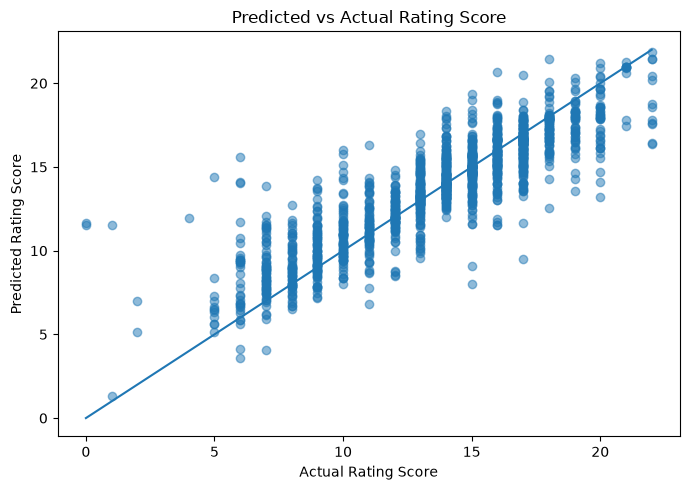

In [26]:
# Predicted vs Actual
plt.figure(figsize=(7, 5))
plt.scatter(y_test_r, best_preds, alpha=0.5)
plt.plot(
    [y_test_r.min(), y_test_r.max()],
    [y_test_r.min(), y_test_r.max()]
)
plt.title('Predicted vs Actual Rating Score')
plt.xlabel('Actual Rating Score')
plt.ylabel('Predicted Rating Score')
plt.tight_layout()
plt.show()

### Observation

Points closer to the diagonal line represent more accurate predictions. A strong regression model should keep most predictions close to this line.

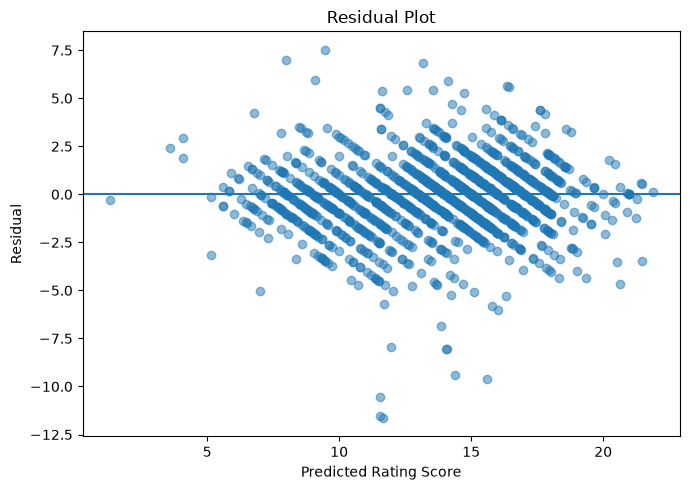

In [27]:
# Residual plot
residuals = y_test_r - best_preds

plt.figure(figsize=(7, 5))
plt.scatter(best_preds, residuals, alpha=0.5)
plt.axhline(0)
plt.title('Residual Plot')
plt.xlabel('Predicted Rating Score')
plt.ylabel('Residual')
plt.tight_layout()
plt.show()

### Observation

Residuals should be reasonably spread around zero without a clear pattern. Large residuals show observations where the model has difficulty predicting the rating score.

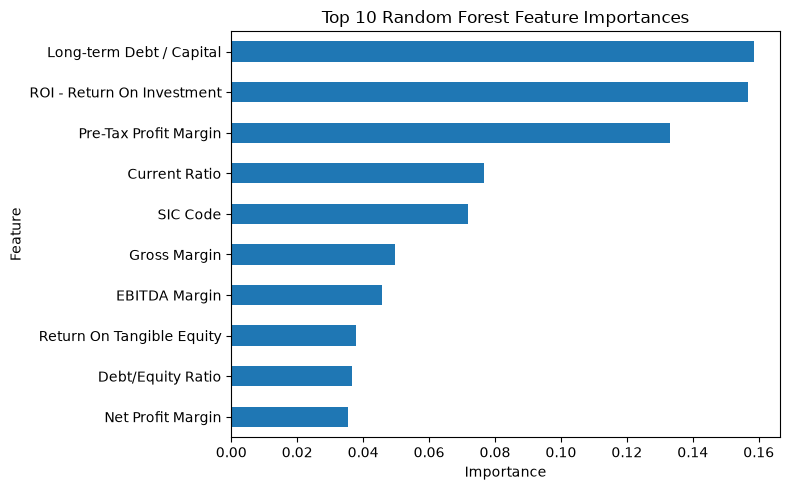

In [28]:
# Feature Importance - Tuned Random Forest

importance = pd.Series(
    rf_search.best_estimator_.feature_importances_,
    index=X_train_r.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
importance.sort_values().plot(kind='barh')

plt.title('Top 10 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

### Observation

The feature importance plot shows which financial variables contribute most to the Random Forest's predictions. Importance indicates the model's use of a feature; it does not by itself prove causation.